<a href="https://colab.research.google.com/github/SreeVarun-29/BDA-REPO/blob/main/Crop_Yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Crop Yield Prediction using Random Forest Regressor
====================================================
A mini project that predicts crop yield based on:
- Remote sensing indices (NDVI, GNDVI, NDWI, SAVI)
- Weather data (temperature, rainfall)
- Soil moisture
- Location (latitude, longitude)
- Crop type

Author: Sree Varun
"""
#Import Libraries:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load and Explore data:

print("=" * 60)
print("CROP YIELD PREDICTION - RANDOM FOREST REGRESSOR")
print("=" * 60)

# Load dataset
df = pd.read_csv('yield_prediction_dataset.csv')
print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Drop empty columns
df = df.drop(columns=['Unnamed: 13', 'Unnamed: 14'], errors='ignore')

CROP YIELD PREDICTION - RANDOM FOREST REGRESSOR

Dataset loaded: 1625 rows, 15 columns


In [ ]:
# Feature Engneering:

print("\n[2] Feature Engineering...")

# Extract month from date (seasonal info matters!)
df['date_of_image'] = pd.to_datetime(df['date_of_image'], format='%d-%m-%Y')
df['month'] = df['date_of_image'].dt.month

# Encode categorical variables
le_field = LabelEncoder()
le_crop = LabelEncoder()

df['field_id_enc'] = le_field.fit_transform(df['field_id'])
df['crop_type_enc'] = le_crop.fit_transform(df['crop_type'])

# Define features and target
FEATURES = ['latitude', 'longitude', 'NDVI', 'GNDVI', 'NDWI', 'SAVI',
            'soil_moisture', 'temperature', 'rainfall', 'month',
            'field_id_enc', 'crop_type_enc']

TARGET = 'yield'

X = df[FEATURES]
y = df[TARGET]

print(f"Features used: {len(FEATURES)}")
for f in FEATURES:
    print(f"  - {f}")


[2] Feature Engineering...
Features used: 12
  - latitude
  - longitude
  - NDVI
  - GNDVI
  - NDWI
  - SAVI
  - soil_moisture
  - temperature
  - rainfall
  - month
  - field_id_enc
  - crop_type_enc


In [ ]:
# Train Test Split:

print("\n[3] Splitting data (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


[3] Splitting data (80% train, 20% test)...
Training samples: 1300
Test samples: 325


In [ ]:
# Train Random Forest:

print("\n[4] Training Random Forest Regressor...")

rf_model = RandomForestRegressor(
    n_estimators=300,      # Number of trees
    max_depth=20,           # Max depth of each tree
    min_samples_split=5,    # Min samples to split a node
    min_samples_leaf=2,     # Min samples in leaf node
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

rf_model.fit(X_train, y_train)
print("Training complete!")


[4] Training Random Forest Regressor...
Training complete!


In [ ]:
# Evaluate Model:

print("\n[5] Evaluating Model...")

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("MODEL PERFORMANCE")
print("=" * 40)
print(f"R2 Score (Accuracy):  {r2:.4f}  ({r2*100:.2f}%)")
print(f"RMSE:                 {rmse:.4f}")
print(f"MAE:                  {mae:.4f}")
print(f"Mean Actual Yield:    {y.mean():.2f}")
print(f"Error % (RMSE/Mean):  {rmse/y.mean()*100:.2f}%")


[5] Evaluating Model...

MODEL PERFORMANCE
R2 Score (Accuracy):  0.9099  (90.99%)
RMSE:                 2.6435
MAE:                  0.8944
Mean Actual Yield:    40.49
Error % (RMSE/Mean):  6.53%


In [ ]:
# Feature Importance:

print("\n[6] Feature Importance Analysis...")

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop Features:")
for _, row in importance_df.iterrows():
    bar = "#" * int(row['importance'] * 50)
    print(f"  {row['feature']:15s} | {row['importance']:.4f} {bar}")


[6] Feature Importance Analysis...

Top Features:
  rainfall        | 0.7722 ######################################
  NDVI            | 0.0892 ####
  SAVI            | 0.0710 ###
  field_id_enc    | 0.0167 
  NDWI            | 0.0121 
  soil_moisture   | 0.0113 
  latitude        | 0.0069 
  GNDVI           | 0.0067 
  temperature     | 0.0057 
  month           | 0.0044 
  longitude       | 0.0020 
  crop_type_enc   | 0.0019 



[7] Generating visualizations...
Saved: yield_prediction_results.png


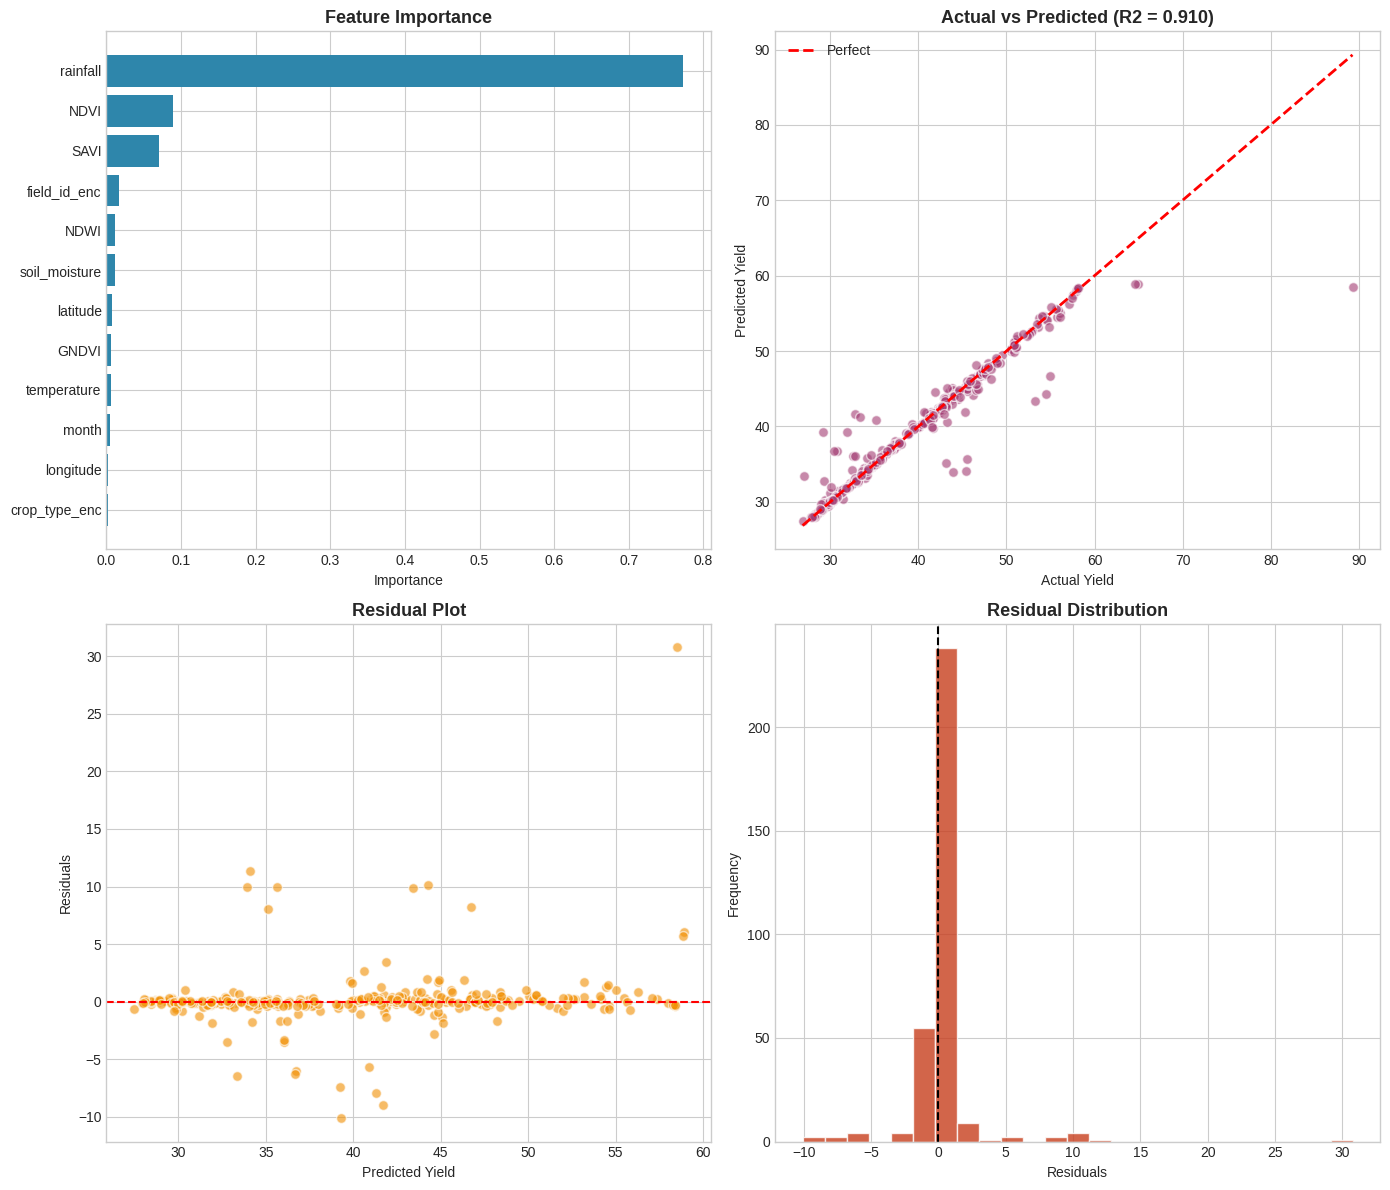

In [ ]:
# Visualizations:

print("\n[7] Generating visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Feature Importance
imp_sorted = importance_df.sort_values('importance', ascending=True)
axes[0, 0].barh(imp_sorted['feature'], imp_sorted['importance'], color='#2E86AB')
axes[0, 0].set_title('Feature Importance', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Importance')

# Plot 2: Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred, alpha=0.6, color='#A23B72', edgecolors='white', s=50)
min_val, max_val = y_test.min(), y_test.max()
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
axes[0, 1].set_xlabel('Actual Yield')
axes[0, 1].set_ylabel('Predicted Yield')
axes[0, 1].set_title(f'Actual vs Predicted (R2 = {r2:.3f})', fontsize=13, fontweight='bold')
axes[0, 1].legend()

# Plot 3: Residuals
residuals = y_test - y_pred
axes[1, 0].scatter(y_pred, residuals, alpha=0.6, color='#F18F01', edgecolors='white', s=50)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Predicted Yield')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot', fontsize=13, fontweight='bold')

# Plot 4: Residual Distribution
axes[1, 1].hist(residuals, bins=25, color='#C73E1D', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(x=0, color='black', linestyle='--')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('yield_prediction_results.png', dpi=150, bbox_inches='tight')
print("Saved: yield_prediction_results.png")
plt.show()

In [ ]:
# Save Model:

print("\n[8] Saving model and encoders...")

joblib.dump(rf_model, 'rf_yield_model.pkl')
joblib.dump(le_crop, 'crop_encoder.pkl')
joblib.dump(le_field, 'field_encoder.pkl')

print("Saved: rf_yield_model.pkl")
print("Saved: crop_encoder.pkl")
print("Saved: field_encoder.pkl")


[8] Saving model and encoders...
Saved: rf_yield_model.pkl
Saved: crop_encoder.pkl
Saved: field_encoder.pkl


In [ ]:
# Prediction Function:

def predict_yield(latitude, longitude, ndvi, gndvi, ndwi, savi,
                  soil_moisture, temperature, rainfall, month,
                  field_id, crop_type):
    """
    Predict crop yield for given inputs.

    Example:
        pred = predict_yield(
            latitude=22.62, longitude=88.50,
            ndvi=0.45, gndvi=0.41, ndwi=-0.41, savi=0.68,
            soil_moisture=25.3, temperature=29.0, rainfall=11.0,
            month=3, field_id='Field_1', crop_type='Rice'
        )
        print(f"Predicted Yield: {pred:.2f}")
    """
    # Encode categoricals
    field_enc = le_field.transform([field_id])[0]
    crop_enc = le_crop.transform([crop_type])[0]

    # Create input array
    input_data = np.array([[latitude, longitude, ndvi, gndvi, ndwi, savi,
                            soil_moisture, temperature, rainfall, month,
                            field_enc, crop_enc]])

    prediction = rf_model.predict(input_data)[0]
    return prediction

In [ ]:
# Demo Prediction:

print("\n[9] Demo Prediction:")
print("-" * 40)

sample = {
    'latitude': 22.625, 'longitude': 88.498,
    'ndvi': 0.45, 'gndvi': 0.41, 'ndwi': -0.41, 'savi': 0.68,
    'soil_moisture': 25.3, 'temperature': 29.0, 'rainfall': 11.0,
    'month': 3, 'field_id': 'Field_1', 'crop_type': 'Rice'
}

pred = predict_yield(**sample)
print(f"Input: Rice crop, Field_1, March")
print(f"Predicted Yield: {pred:.2f}")

print("\n" + "=" * 60)
print("MINI PROJECT COMPLETE!")
print("=" * 60)


[9] Demo Prediction:
----------------------------------------
Input: Rice crop, Field_1, March
Predicted Yield: 42.63

MINI PROJECT COMPLETE!


In [1]:
!git clone https://github.com/SreeVarun-29/Yield-Prediction.git

Cloning into 'Yield-Prediction'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 274.90 KiB | 3.35 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [2]:
!cp "/content/YourNotebook.ipynb" .

cp: cannot stat '/content/YourNotebook.ipynb': No such file or directory


In [3]:
!ls /content

sample_data  Yield-Prediction


In [4]:
import os
print(os.getcwd())

/content
